In [108]:
import warnings
import numpy as np
import pandas as pd
import iris
import iris.cube
import geopandas as gpd
import os
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from iris.warnings import IrisCfMissingVarWarning
import time

warnings.filterwarnings("ignore", category=IrisCfMissingVarWarning)
warnings.filterwarnings("ignore", message=".*ensemble_member_id.*")
iris.FUTURE.date_microseconds = True
iris.FUTURE.datum_support = True

from functions import (
    get_rainfall_cube,
    build_mask,
    apply_mask_to_cube,
    find_max_precip_location,
    get_rainfall_event_details,
)

# ── Config ────────────────────────────────────────────────────────────────────
MOLLY_DIR_FF     = "/scratch/hydro4/users/kv25483/FutureFlood/"
RAINFALL_CSV_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/"
OUT_DIR          = "/scratch/hydro4/users/kv25483/FutureFlood/Data/PeakIndices/"
METHOD           = "center_point"
ENSEMBLE_MEMBERS = ['01', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '15']

catchments       = gpd.read_file(MOLLY_DIR_FF + "Data/CatchmentShapefiles/hyd_areas_GB_with_subcatchments.shp")
catchment_lookup = pd.read_csv("/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/CEH_catchments/CEH_IHU_with_coastline/hyd_areas_GB_with_subcatchments_no_spaces.csv")
catchment_lookup_dict = dict(zip(catchment_lookup["HA_NUM"], catchment_lookup["HA_NAME"]))

# ── Per-worker globals ────────────────────────────────────────────────────────
_CATCHMENT_POLY = None
_RAIN_CUBES     = {}   # {year: (rain_cube_masked, mask_2d)}


def _init_worker(catchment_num):
    global _CATCHMENT_POLY, _RAIN_CUBES
    boundary_gdf    = catchments[catchments['HA_NUM'] == str(catchment_num)]
    _CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    _RAIN_CUBES     = {}


# def _process_event(args):
#     catchment_num, event_num, rainfall_events, rainfall_cube_dir, ens_num = args
#     global _CATCHMENT_POLY, _RAIN_CUBES

#     details = get_rainfall_event_details(rainfall_events, event_num)
#     year    = details['yr']

#     if year not in _RAIN_CUBES:
#         rain_cube         = get_rainfall_cube(year, ens_num, rainfall_cube_dir)
#         mask_2d           = build_mask(rain_cube, _CATCHMENT_POLY, method=METHOD)
#         rain_cube_masked  = apply_mask_to_cube(rain_cube, mask_2d)
#         _RAIN_CUBES[year] = (rain_cube_masked, mask_2d)
#     else:
#         rain_cube_masked, mask_2d = _RAIN_CUBES[year]

#     peak = find_max_precip_location(
#         rain_cube_masked, mask_2d,
#         details['start_idx'], details['stop_idx']
#     )

#     return {
#         'catchment':   catchment_num,
#         'ensemble':    ens_num,
#         'event_num':   event_num,
#         'year':        details['yr'],
#         'start_idx':   details['start_idx'],
#         'stop_idx':    details['stop_idx'],
#         'x_idx':       peak['x_idx'],
#         'y_idx':       peak['y_idx'],
#         't_global':    peak['t_global'],
#         'x_coord':     peak['x_coord'],
#         'y_coord':     peak['y_coord'],
#         'max_precip':  peak['max_precip'],
#     }


#      return None


def run_catchment(catchment_num, n_workers=8):
    catchment_name   = catchment_lookup_dict[str(catchment_num)]
    catchment_out    = os.path.join(OUT_DIR, f"Catchment_{catchment_num}")
    out_path         = os.path.join(catchment_out, "peak_indices.csv")
    os.makedirs(catchment_out, exist_ok=True)

    if os.path.exists(out_path):
        print(f"  Catchment {catchment_num}: already done, skipping.")
        return

    all_rows = []

    for ens in tqdm(ENSEMBLE_MEMBERS, desc=f"Catchment {catchment_num}"):
        rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens}/"
        rainfall_events   = pd.read_csv(
            RAINFALL_CSV_DIR + f"{catchment_name}_{ens}_full_events_with_event_nums.csv")

        args_list = [
            (catchment_num, event_num, rainfall_events, rainfall_cube_dir, ens)
            for event_num in range(1, len(rainfall_events) + 1)]

        with Pool(
            processes=n_workers,
            initializer=_init_worker,
            initargs=(catchment_num,)
        ) as pool:
            for result in tqdm(
                pool.imap_unordered(_process_event, args_list),
                total=len(args_list),
                desc=f"  EM {ens}",
                leave=False
            ):
                if result is not None:
                    all_rows.append(result)

    pd.DataFrame(all_rows).sort_values(
        ['ensemble', 'event_num']
    ).to_csv(out_path, index=False)
    print(f"  Saved {len(all_rows)} rows to {out_path}")


def main():
    import re
    files             = os.listdir("/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/tifs/")
    catchment_numbers = {re.search(r'Ens15_(.+)', f).group(1) for f in files if re.search(r'Ens15_(.+)', f)}
    catchments_to_run = sorted(catchment_numbers)[:2]
    print(f"{len(catchments_to_run)} catchments to process")

    for c in catchments_to_run:
        run_catchment(c)


# if __name__ == "__main__":
#     import multiprocessing as mp
#     mp.set_start_method("spawn", force=True)
#     main()

In [3]:
import re
files             = os.listdir("/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/tifs/")
catchment_numbers = {re.search(r'Ens15_(.+)', f).group(1) for f in files if re.search(r'Ens15_(.+)', f)}
catchments_to_run = sorted(catchment_numbers)[:2]
print(f"{len(catchments_to_run)} catchments to process")

2 catchments to process


In [13]:
def filter_closer_to_catchment(cube, catchment_poly, plot=False, boundary_gdf = None):

    minx, miny, maxx, maxy = catchment_poly.bounds

    buffer = 0  # metres

    constraint = iris.Constraint( projection_x_coordinate=lambda x: (minx - buffer) <= x <= (maxx + buffer),
        projection_y_coordinate=lambda y: (miny - buffer) <= y <= (maxy + buffer))

    sub_cube = cube.extract(constraint)
    
    if plot==True:
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': ccrs.OSGB()})
        qplt.pcolormesh(sub_cube[2], axes=ax, cmap = 'Blues', edgecolor='black', linewidth=0.5)
        boundary_gdf.boundary.plot(ax=ax, color='black');
        
    return sub_cube

def find_max_precip_location(cube, mask_2d, start_idx, stop_idx):
    """Find peak precipitation location and time within the event window.
    Works directly on numpy arrays for speed rather than iris cube operations.
    """
    # Apply mask and extract event window as raw numpy array
    data = cube.data.copy().astype(float)
    data[:, ~mask_2d] = np.nan
    subset = data[start_idx:stop_idx, :, :]

    flat_index = np.nanargmax(subset)
    t_local, y_idx, x_idx = np.unravel_index(flat_index, subset.shape)

    return {
        'max_precip': subset[t_local, y_idx, x_idx],
        't_global':   t_local + start_idx,
        'x_idx':      int(x_idx),
        'y_idx':      int(y_idx),
        'x_coord':    cube.coord('projection_x_coordinate').points[x_idx],
        'y_coord':    cube.coord('projection_y_coordinate').points[y_idx],}

def get_rainfall_cube(yr, ENS_NUM, RAINFALLDIR, _CATCHMENT_POLY):
    """Load and concatenate monthly rainfall cubes for the event year.
    Loads Dec of previous year + Jan-Nov of target year.
    """
    files = [
        f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr-1}1201-{yr-1}1230.nc"]
    for m in range(1, 12):
        files.append(
            f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr}{m:02d}01-{yr}{m:02d}30.nc")

    monthly_cubes = iris.cube.CubeList()
    for f in files:
        cube = iris.load(f)[1]
        cube.attributes = {}
        monthly_cubes.append(cube)
    
    year_cube = monthly_cubes.concatenate_cube()
    
    # Filter to catchment
    # year_cube = extract_catchment_cube(year_cube, _CATCHMENT_POLY, True,boundary_gdf)
    
    return year_cube

In [4]:
catchment_num = 1
catchment_name   = catchment_lookup_dict[str(catchment_num)]
catchment_out    = os.path.join(OUT_DIR, f"Catchment_{catchment_num}")
out_path         = os.path.join(catchment_out, "peak_indices.csv")
os.makedirs(catchment_out, exist_ok=True)

boundary_gdf    = catchments[catchments['HA_NUM'] == str(catchment_num)]
_CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

if os.path.exists(out_path):
    print(f"  Catchment {catchment_num}: already done, skipping.")

all_rows = []

# for ens in tqdm(ENSEMBLE_MEMBERS, desc=f"Catchment {catchment_num}"):
#     rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens}/"
#     rainfall_events   = pd.read_csv(
#         RAINFALL_CSV_DIR + f"{catchment_name}_{ens}_full_events_with_event_nums.csv")

#     args_list = [
#         (catchment_num, event_num, rainfall_events, rainfall_cube_dir, ens)
#         for event_num in range(1, len(rainfall_events) + 1)]
    


In [77]:
import iris

def subset_cube_to_bbox(cube, catchment_poly, buffer=0):
    """
    Quickly subset cube to catchment bounding box (+ optional buffer)
    """
    minx, miny, maxx, maxy = catchment_poly.bounds

    constraint = iris.Constraint(
        projection_x_coordinate=lambda x: (minx - buffer) <= x <= (maxx + buffer),
        projection_y_coordinate=lambda y: (miny - buffer) <= y <= (maxy + buffer)
    )

    sub_cube = cube.extract(constraint)

    if sub_cube is None:
        raise ValueError("No data found within bounding box")

    return sub_cube

import numpy as np
from rasterio.features import geometry_mask
from rasterio.transform import from_origin
from shapely import contains_xy
from shapely.geometry import box
from shapely.strtree import STRtree



def mask_cube_with_catchment(sub_cube, catchment_poly, method="center_point"):
    """
    Build a 2D boolean mask for the catchment polygon.
    Returns (ny, nx) boolean array.
    """

    x = sub_cube.coord('projection_x_coordinate').points
    y = sub_cube.coord('projection_y_coordinate').points
    xx, yy = np.meshgrid(x, y)

    if method == "center_point":
        # 🚀 Fastest
        mask = contains_xy(catchment_poly, xx.ravel(), yy.ravel())
        mask = mask.reshape(xx.shape)

    elif method == "raster":
        # 🚀 Fast + robust (recommended alternative)
        from rasterio.features import geometry_mask
        from rasterio.transform import from_origin

        dx = np.diff(x).mean()
        dy = np.diff(y).mean()

        transform = from_origin(
            x.min() - dx / 2,
            y.max() + dy / 2,
            dx,
            dy
        )

        mask = geometry_mask(
            [catchment_poly],
            transform=transform,
            invert=True,
            out_shape=(len(y), len(x))
        )

        # Fix orientation if needed
        if y[1] > y[0]:
            mask = np.flipud(mask)

    elif method == "full_cell":
        # 🐢 Slow but most geometrically correct
        dx = x[1] - x[0]
        dy = y[1] - y[0]

        cells = [
            box(xi - dx/2, yi - dy/2, xi + dx/2, yi + dy/2)
            for yi, xi in zip(yy.ravel(), xx.ravel())
        ]

        tree = STRtree(cells)
        hits = tree.query(catchment_poly, predicate='intersects')

        mask = np.zeros(len(cells), dtype=bool)
        mask[hits] = True
        mask = mask.reshape(xx.shape)
        
    masked_data = np.where(mask, sub_cube.data, np.nan)
    return sub_cube.copy(data=masked_data)

#     else:
#         print("method must be 'center_point', 'raster', or 'full_cell'")
#         raise ValueError("method must be 'center_point', 'raster', or 'full_cell'")

    

def extract_catchment_cube(cube, catchment_poly, method, buffer=0):
    start_time1 = time.time()
    sub_cube = subset_cube_to_bbox(cube, catchment_poly, buffer)
    end_time1 = time.time()
    time_elapsed1 = end_time1 - start_time1 # round(end_time - start_time,3)
    print(f"Time for subsetting: {round(time_elapsed1,2)} seconds")
    
    start_time2 = time.time()
    masked_cube = mask_cube_with_catchment(sub_cube, catchment_poly, method)
    end_time2 = time.time()
    time_elapsed2 = end_time2 - start_time2 # round(end_time - start_time,3)
    print(f"Time for masking: {round(time_elapsed2,2)} seconds")
    
    time_elapsed_total = end_time2 - start_time1 # round(end_time - start_time,3)
    print(f"Total time:: {round(time_elapsed_total,2)} seconds")
    return masked_cube



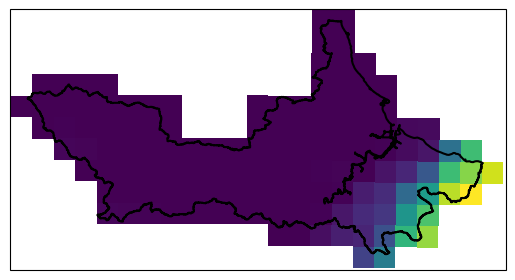

In [79]:
catchment_num = 25
catchment_name   = catchment_lookup_dict[str(catchment_num)]
catchment_out    = os.path.join(OUT_DIR, f"Catchment_{catchment_num}")
out_path         = os.path.join(catchment_out, "peak_indices.csv")
os.makedirs(catchment_out, exist_ok=True)

year = 2020
ens_num = '01'
ens = '01'
rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens}/"
rainfall_events   = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens}_full_events_with_event_nums.csv")

#### Prepare data for this catchment and ensemble member
boundary_gdf    = catchments[catchments['HA_NUM'] == str(catchment_num)]
_CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

year_cube = get_rainfall_cube(year, ens_num, rainfall_cube_dir, _CATCHMENT_POLY)
year_cube = extract_catchment_cube(year_cube, _CATCHMENT_POLY, 'full_cell')

# Check if correct
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

cube_slice = year_cube[1, :, :]

iplt.pcolormesh(cube_slice, axes=ax)

# Make sure your GeoDataFrame is in the same CRS!
boundary_gdf.to_crs(epsg=4326).boundary.plot(ax=ax, color='black')

plt.show()

In [107]:


### For one event, find location of peak
event_num = 1
this_event = rainfall_events.iloc[event_num]
start_idx = int(this_event['start_indices'])
stop_idx  = int(this_event['stop_indices'])

find_max_precip_location(year_cube,start_idx, stop_idx )

{'max_precip': np.float32(0.00030740234),
 't_global': np.int64(6531),
 'x_idx': 1,
 'y_idx': 7,
 'x_coord': np.float64(372500.0),
 'y_coord': np.float64(532500.0)}

In [23]:
import time
import matplotlib.pyplot as plt
import rasterio as rasterio
import cartopy.crs as ccrs
import iris.plot as iplt

In [55]:
start_time = time.time()

rain_cube = get_rainfall_cube(year, ens_num, rainfall_cube_dir, _CATCHMENT_POLY)
mask_2d           = build_mask(rain_cube, _CATCHMENT_POLY, method=METHOD)
rain_cube_masked  = apply_mask_to_cube(rain_cube, mask_2d)

end_time = time.time()
time_elapsed = end_time - start_time # round(end_time - start_time,3)
print(f"{round(time_elapsed,2)} seconds")

17.46 seconds


In [19]:
catchment_num, event_num, rainfall_events, rainfall_cube_dir, ens_num = args_list[0]
global _CATCHMENT_POLY, _RAIN_CUBES

details = get_rainfall_event_details(rainfall_events, event_num)
year    = details['yr']

if year not in _RAIN_CUBES:
    rain_cube         = get_rainfall_cube(year, ens_num, rainfall_cube_dir)
    mask_2d           = build_mask(rain_cube, _CATCHMENT_POLY, method=METHOD)
    rain_cube_masked  = apply_mask_to_cube(rain_cube, mask_2d)
    _RAIN_CUBES[year] = (rain_cube_masked, mask_2d)
else:
    rain_cube_masked, mask_2d = _RAIN_CUBES[year]

peak = find_max_precip_location(
    rain_cube_masked, mask_2d,
    details['start_idx'], details['stop_idx'])

test =  {
    'catchment':   catchment_num,
    'ensemble':    ens_num,
    'event_num':   event_num,
    'year':        details['yr'],
    'start_idx':   details['start_idx'],
    'stop_idx':    details['stop_idx'],
    'x_idx':       peak['x_idx'],
    'y_idx':       peak['y_idx'],
    't_global':    peak['t_global'],
    'x_coord':     peak['x_coord'],
    'y_coord':     peak['y_coord'],
    'max_precip':  peak['max_precip'],
}

ValueError: All-NaN slice encountered